# Applied Diffusion Notebook 2 — Training and Evaluating a Small DDPM

This notebook continues from the mechanics notebook.

Here the goal is to train a compact DDPM on MNIST or FashionMNIST.

Main components:

1. Dataset and transforms
2. Diffusion schedule object
3. Small UNet-style denoiser
4. Training loop
5. Sampling loop
6. Evaluation and diagnostics

This notebook is intentionally small enough for learning and debugging. It is not meant to compete with large diffusion models.

In [2]:
# If needed:
# !pip install torch torchvision matplotlib tqdm

import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1. Configuration

In [5]:
@dataclass
class TrainConfig:
    dataset_name: str = "MNIST"  # "MNIST" or "FashionMNIST"
    image_size: int = 28
    image_channels: int = 1

    timesteps: int = 300  # 
    beta_schedule: str = "cosine"  # "linear" or "cosine"

    batch_size: int = 128
    epochs: int = 5
    lr: float = 2e-4

    base_channels: int = 64
    time_dim: int = 256

    sample_every_epochs: int = 1
    num_sample_images: int = 64

    out_dir: str = "./ddpm_outputs"

cfg = TrainConfig()
Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)

cfg

TrainConfig(dataset_name='MNIST', image_size=28, image_channels=1, timesteps=300, beta_schedule='cosine', batch_size=128, epochs=5, lr=0.0002, base_channels=64, time_dim=256, sample_every_epochs=1, num_sample_images=64, out_dir='./ddpm_outputs')

## 2. Dataset

Images are scaled from `[0, 1]` to `[-1, 1]`.

For your own dataset, the important part is to return tensors with shape `[B, C, H, W]` and values approximately in `[-1, 1]`.

In [6]:
def build_dataset(cfg: TrainConfig):
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])

    if cfg.dataset_name == "MNIST":
        dataset_cls = datasets.MNIST
    elif cfg.dataset_name == "FashionMNIST":
        dataset_cls = datasets.FashionMNIST
    else:
        raise ValueError(f"Unknown dataset: {cfg.dataset_name}")

    train_set = dataset_cls(root="./data", train=True, download=True, transform=transform)
    test_set = dataset_cls(root="./data", train=False, download=True, transform=transform)

    return train_set, test_set


train_set, test_set = build_dataset(cfg)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

x, y = next(iter(train_loader))
x.shape, x.min().item(), x.max().item()

(torch.Size([128, 1, 28, 28]), -1.0, 1.0)

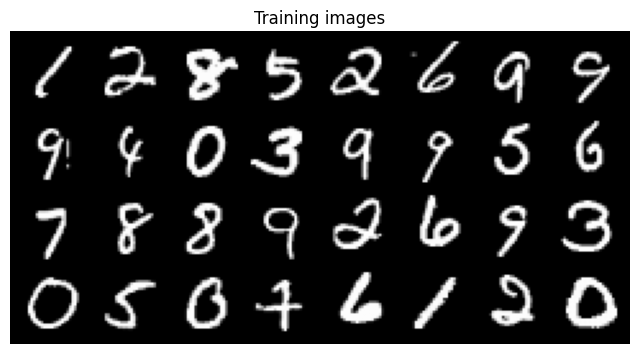

In [7]:
def to_img(x: torch.Tensor) -> torch.Tensor:
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


def show_grid(x: torch.Tensor, nrow: int = 8, title: Optional[str] = None) -> None:
    x = x.detach().cpu()
    grid = make_grid(to_img(x), nrow=nrow)
    plt.figure(figsize=(nrow, nrow))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


show_grid(x[:32], nrow=8, title="Training images")

## 3. Diffusion schedule and process object

This object wraps the critical functions:

- `q_sample`
- `predict_x0_from_noise`
- `q_posterior_mean_variance`
- `p_sample`
- `sample`

In [9]:
def linear_beta_schedule(timesteps: int, beta_start: float = 1e-4, beta_end: float = 2e-2) -> torch.Tensor:
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps: int, s: float = 0.008) -> torch.Tensor:
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alpha_bar = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
    return betas.clamp(1e-4, 0.999)


def extract(a: torch.Tensor, t: torch.Tensor, x_shape: Tuple[int, ...]) -> torch.Tensor:
    b = t.shape[0]
    out = a.gather(dim=0, index=t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))


class GaussianDiffusion:
    def __init__(self, timesteps: int, beta_schedule: str = "cosine", device: torch.device = torch.device("cpu")):
        self.timesteps = timesteps
        self.device = device

        if beta_schedule == "linear":
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == "cosine":
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"Unknown beta schedule: {beta_schedule}")

        self.betas = betas.to(device)
        self.alphas = (1.0 - self.betas).to(device)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)
        self.alpha_bars_prev = F.pad(self.alpha_bars[:-1], (1, 0), value=1.0).to(device)

        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)
        self.posterior_variance = self.betas * (1.0 - self.alpha_bars_prev) / (1.0 - self.alpha_bars)
        self.posterior_log_variance_clipped = torch.log(self.posterior_variance.clamp(min=1e-20))
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alpha_bars_prev) / (1.0 - self.alpha_bars)
        self.posterior_mean_coef2 = (1.0 - self.alpha_bars_prev) * torch.sqrt(self.alphas) / (1.0 - self.alpha_bars)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x0)

        return (
            extract(self.sqrt_alpha_bars, t, x0.shape) * x0
            + extract(self.sqrt_one_minus_alpha_bars, t, x0.shape) * noise
        )

    def predict_x0_from_noise(self, xt: torch.Tensor, t: torch.Tensor, noise_pred: torch.Tensor) -> torch.Tensor:
        return (
            xt - extract(self.sqrt_one_minus_alpha_bars, t, xt.shape) * noise_pred
        ) / extract(self.sqrt_alpha_bars, t, xt.shape)

    def q_posterior_mean_variance(self, x0: torch.Tensor, xt: torch.Tensor, t: torch.Tensor):
        posterior_mean = (
            extract(self.posterior_mean_coef1, t, xt.shape) * x0
            + extract(self.posterior_mean_coef2, t, xt.shape) * xt
        )
        posterior_variance = extract(self.posterior_variance, t, xt.shape)
        posterior_log_variance = extract(self.posterior_log_variance_clipped, t, xt.shape)
        return posterior_mean, posterior_variance, posterior_log_variance

    @torch.no_grad()
    def p_sample(self, model: nn.Module, xt: torch.Tensor, t: torch.Tensor, t_index: int) -> torch.Tensor:
        noise_pred = model(xt, t)
        x0_pred = self.predict_x0_from_noise(xt, t, noise_pred).clamp(-1.0, 1.0)
        posterior_mean, _, posterior_logvar = self.q_posterior_mean_variance(x0_pred, xt, t)

        if t_index == 0:
            return posterior_mean

        noise = torch.randn_like(xt)
        return posterior_mean + torch.exp(0.5 * posterior_logvar) * noise

    @torch.no_grad()
    def sample(self, model: nn.Module, shape: Tuple[int, int, int, int], save_intermediates: bool = False, intermediate_every: int = 50):
        model.eval()
        x = torch.randn(shape, device=self.device)
        intermediates = []

        for i in reversed(range(self.timesteps)):
            t = torch.full((shape[0],), i, device=self.device, dtype=torch.long)
            x = self.p_sample(model, x, t, i)

            if save_intermediates and (i % intermediate_every == 0 or i == self.timesteps - 1):
                intermediates.append(x.detach().cpu())

        if save_intermediates:
            return x, intermediates
        return x


diffusion = GaussianDiffusion(cfg.timesteps, cfg.beta_schedule, device)

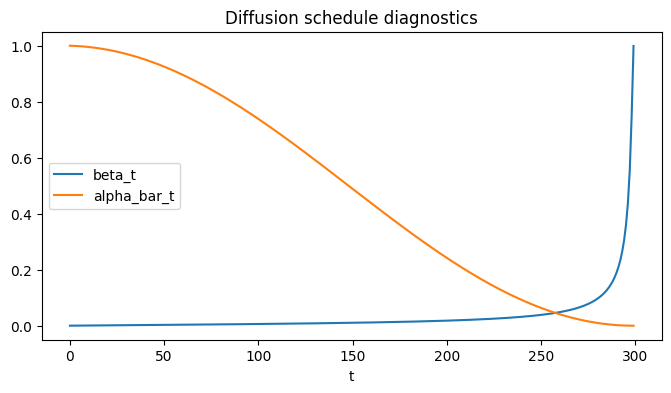

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(diffusion.betas.detach().cpu().numpy(), label="beta_t")
plt.plot(diffusion.alpha_bars.detach().cpu().numpy(), label="alpha_bar_t")
plt.title("Diffusion schedule diagnostics")
plt.xlabel("t")
plt.legend()
plt.show()

## 4. Small UNet-style denoising model

This compact model uses:

- timestep embedding
- residual blocks
- downsampling
- bottleneck
- upsampling
- skip connections

It predicts the noise $\epsilon$ that was added to $x_0$.

In [11]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half_dim = self.dim // 2
        scale = math.log(10000) / (half_dim - 1)
        frequencies = torch.exp(torch.arange(half_dim, device=device) * -scale)
        args = t[:, None].float() * frequencies[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.block1 = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class SmallUNet(nn.Module):
    def __init__(self, image_channels: int = 1, base_channels: int = 64, time_dim: int = 256):
        super().__init__()
        c = base_channels
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.init_conv = nn.Conv2d(image_channels, c, 3, padding=1)
        self.down1 = ResBlock(c, c, time_dim)
        self.downsample1 = Downsample(c)
        self.down2 = ResBlock(c, c * 2, time_dim)
        self.downsample2 = Downsample(c * 2)
        self.mid1 = ResBlock(c * 2, c * 4, time_dim)
        self.mid2 = ResBlock(c * 4, c * 2, time_dim)
        self.upsample2 = Upsample(c * 2)
        self.up2 = ResBlock(c * 4, c, time_dim)
        self.upsample1 = Upsample(c)
        self.up1 = ResBlock(c * 2, c, time_dim)
        self.final = nn.Sequential(nn.GroupNorm(8, c), nn.SiLU(), nn.Conv2d(c, image_channels, 3, padding=1))

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        x = self.init_conv(x)
        h1 = self.down1(x, t_emb)
        x = self.downsample1(h1)
        h2 = self.down2(x, t_emb)
        x = self.downsample2(h2)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)
        x = self.upsample2(x)
        x = torch.cat([x, h2], dim=1)
        x = self.up2(x, t_emb)
        x = self.upsample1(x)
        x = torch.cat([x, h1], dim=1)
        x = self.up1(x, t_emb)
        return self.final(x)


model = SmallUNet(cfg.image_channels, cfg.base_channels, cfg.time_dim).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {num_params:,}")

xb, _ = next(iter(train_loader))
xb = xb.to(device)
tb = torch.randint(0, cfg.timesteps, (xb.shape[0],), device=device).long()
out = model(xb, tb)
print("Input:", xb.shape)
print("Output:", out.shape)

Number of parameters: 2,990,081
Input: torch.Size([128, 1, 28, 28])
Output: torch.Size([128, 1, 28, 28])


## 5. DDPM loss

Training target:

$$
\epsilon_\theta(x_t,t) \approx \epsilon
$$

Loss:

$$
\mathcal{L}_{simple}
=
\left\|
\epsilon - \epsilon_\theta(x_t,t)
\right\|_2^2
$$

In [12]:
def ddpm_loss(model: nn.Module, diffusion: GaussianDiffusion, x0: torch.Tensor) -> torch.Tensor:
    batch_size = x0.shape[0]
    t = torch.randint(0, diffusion.timesteps, (batch_size,), device=x0.device).long()
    noise = torch.randn_like(x0)
    xt = diffusion.q_sample(x0=x0, t=t, noise=noise)
    noise_pred = model(xt, t)
    return F.mse_loss(noise_pred, noise)

## 6. Training loop

For a quick first run:

- keep `epochs=1` or `epochs=2`
- use MNIST
- use CUDA if available

Good samples may require more epochs.

training:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 001 | train loss: 0.08818


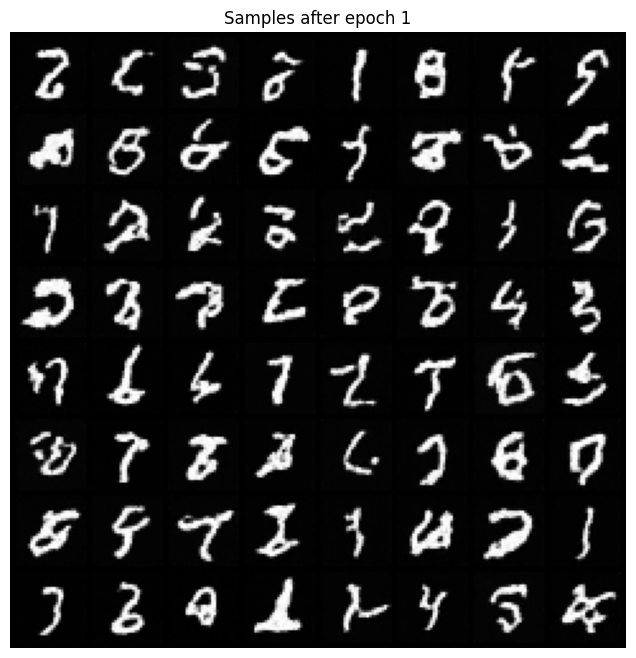

Saved samples to: ddpm_outputs/samples_epoch_001.png


training:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 002 | train loss: 0.04979


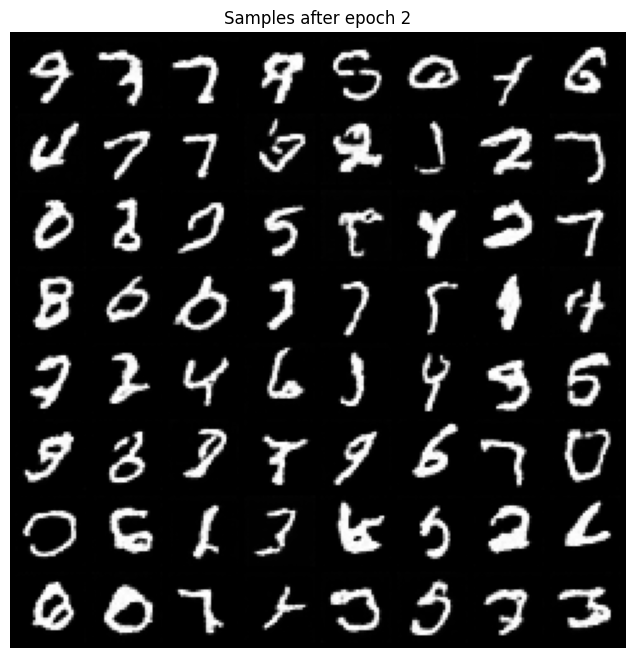

Saved samples to: ddpm_outputs/samples_epoch_002.png


training:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 003 | train loss: 0.04539


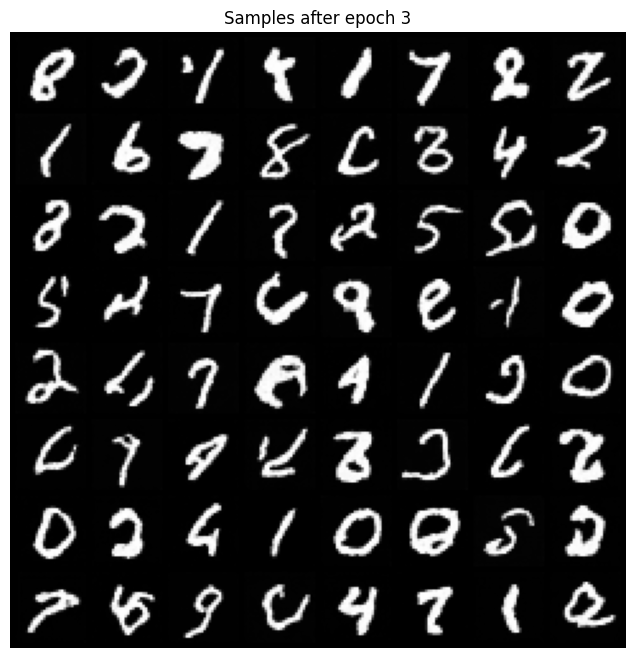

Saved samples to: ddpm_outputs/samples_epoch_003.png


training:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 004 | train loss: 0.04363


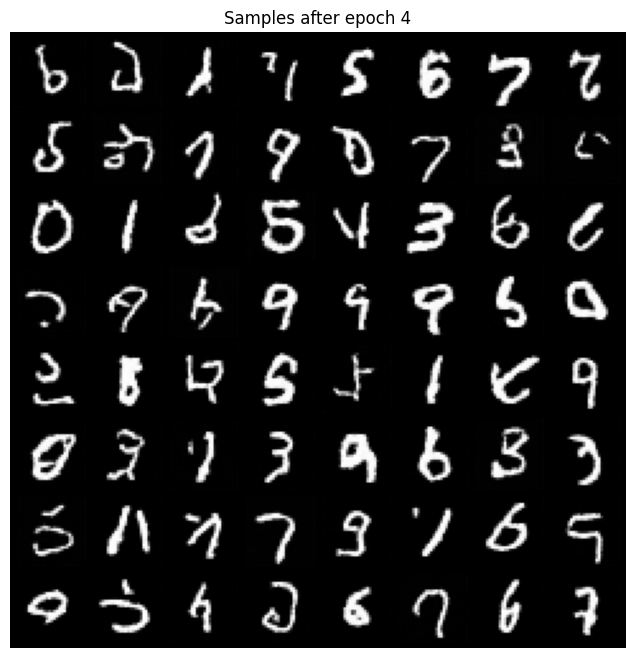

Saved samples to: ddpm_outputs/samples_epoch_004.png


training:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 005 | train loss: 0.04245


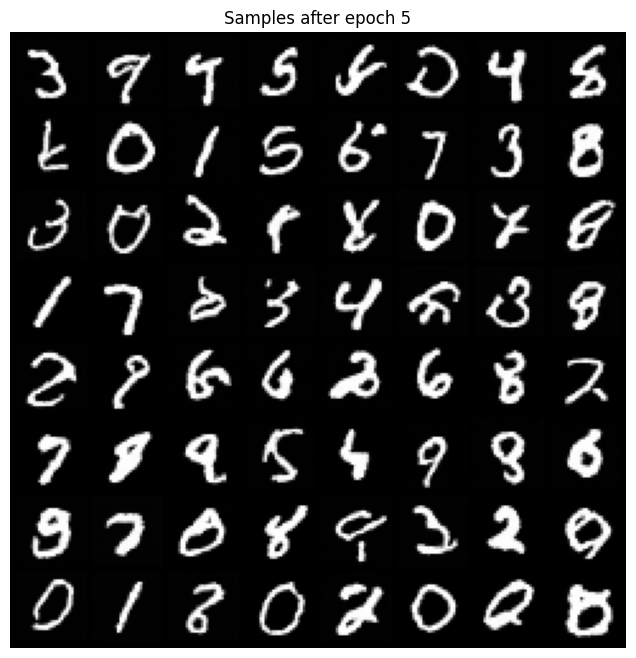

Saved samples to: ddpm_outputs/samples_epoch_005.png


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
train_losses: List[float] = []


def train_one_epoch(model: nn.Module, loader, optimizer: torch.optim.Optimizer, diffusion: GaussianDiffusion, device: torch.device) -> float:
    model.train()
    losses = []
    pbar = tqdm(loader, desc="training", leave=False)

    for x0, _ in pbar:
        x0 = x0.to(device)
        loss = ddpm_loss(model, diffusion, x0)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=sum(losses[-50:]) / len(losses[-50:]))

    return float(sum(losses) / len(losses))


@torch.no_grad()
def save_samples(epoch: int):
    samples = diffusion.sample(
        model=model,
        shape=(cfg.num_sample_images, cfg.image_channels, cfg.image_size, cfg.image_size),
    )
    save_path = Path(cfg.out_dir) / f"samples_epoch_{epoch:03d}.png"
    save_image(to_img(samples), save_path, nrow=int(math.sqrt(cfg.num_sample_images)))
    show_grid(samples[:64], nrow=8, title=f"Samples after epoch {epoch}")
    print(f"Saved samples to: {save_path}")


for epoch in range(1, cfg.epochs + 1):
    avg_loss = train_one_epoch(model, train_loader, optimizer, diffusion, device)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch:03d} | train loss: {avg_loss:.5f}")

    if epoch % cfg.sample_every_epochs == 0:
        save_samples(epoch)

    ckpt_path = Path(cfg.out_dir) / "last_model.pt"
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "cfg": cfg.__dict__,
        "train_losses": train_losses,
    }, ckpt_path)

## 7. Loss curve

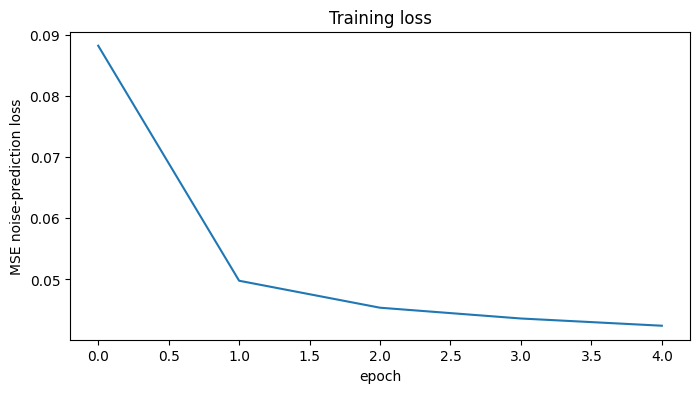

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("MSE noise-prediction loss")
plt.show()

## 8. Qualitative evaluation: denoising trajectory

This shows whether the reverse chain gradually turns Gaussian noise into image-like structure.

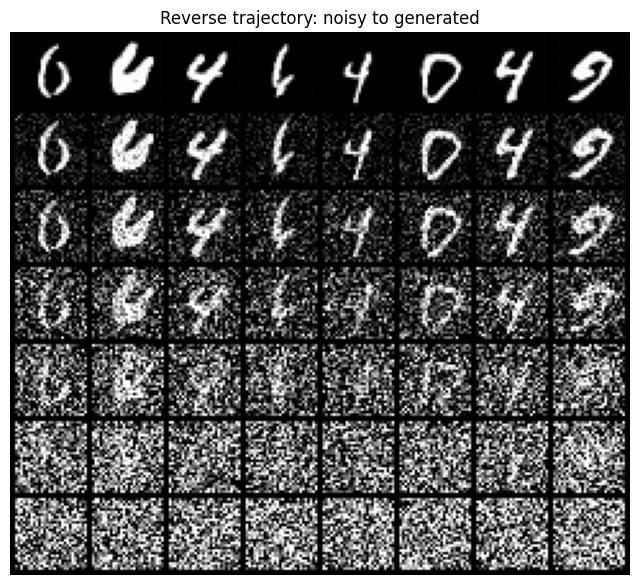

In [15]:
@torch.no_grad()
def show_reverse_trajectory():
    _, intermediates = diffusion.sample(
        model=model,
        shape=(8, cfg.image_channels, cfg.image_size, cfg.image_size),
        save_intermediates=True,
        intermediate_every=max(1, cfg.timesteps // 6),
    )
    trajectory = list(reversed(intermediates))
    batch = torch.cat([x[:8] for x in trajectory], dim=0)
    show_grid(batch, nrow=8, title="Reverse trajectory: noisy to generated")


show_reverse_trajectory()

## 9. Forward-process sanity check

This verifies that the diffusion process itself is behaving correctly.

Rows show increasing noise level.

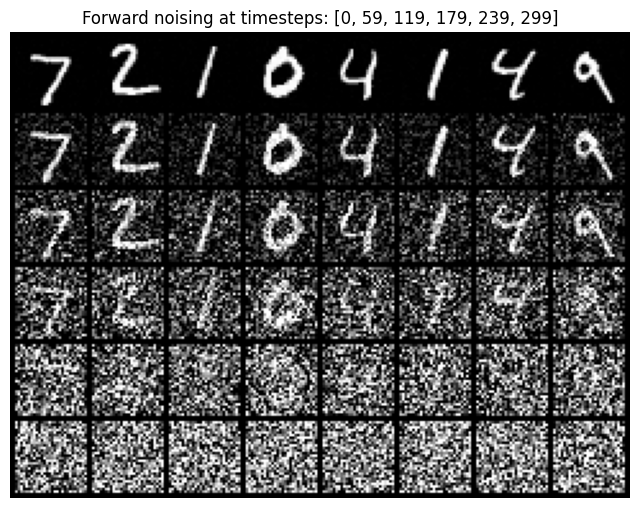

In [16]:
@torch.no_grad()
def show_forward_noising():
    x0, _ = next(iter(test_loader))
    x0 = x0[:8].to(device)
    steps = torch.linspace(0, cfg.timesteps - 1, 6).long().tolist()

    rows = []
    for step in steps:
        t = torch.full((x0.shape[0],), step, device=device, dtype=torch.long)
        xt = diffusion.q_sample(x0, t)
        rows.append(xt)

    batch = torch.cat(rows, dim=0)
    show_grid(batch, nrow=8, title=f"Forward noising at timesteps: {steps}")


show_forward_noising()